<a href="https://colab.research.google.com/github/YusufSY03/Project_ProbStat_Kel9/blob/main/ProbStat_Kel9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Projek Statistika dan Probabilitas
##Analisis Faktor-Faktor yang Memengaruhi Indeks Massa Tubuh (BMI) Remaja di Indonesia
##Kelompok 9
##Kelas 3 TI B

###BAGIAN 0 - Persiapan Colab

In [3]:
import pandas as pd
# Mendefinisikan path dataset
path = "3TIB_09_ObesityDataset.xlsx"

dataraw = pd.read_excel(path)

print("Tampilan 5 baris pertama dataraw:")
print(dataraw.head())

Tampilan 5 baris pertama dataraw:
      Gender  Age  Height_m  Weight_kg History of Obesity  \
0  Perempuan   10      1.32       26.0              Tidak   
1  Perempuan   10      1.45       36.0              Tidak   
2  Laki-laki   18      1.81       60.0              Tidak   
3  Laki-laki   18      1.73       84.0              Tidak   
4  Laki-laki   18      1.70       80.0              Tidak   

  High-calorie Food Consumption  Daily Vegetable Consumption  \
0                            Ya                            2   
1                            Ya                            2   
2                            Ya                            2   
3                            Ya                            2   
4                            Ya                            2   

   Main Meal Frequency Snack Consumption Frequency Smoking Habit  \
0                    2               Kadang-kadang         Tidak   
1                    5                      Sering         Tidak   
2         

###BAGIAN 1 - Eksplorasi dan Pembersihan Data Dasar

In [4]:
# Cek dimensi data awal
print("Shape awal:", dataraw.shape)

# Cek jumlah baris duplikat
print("Jumlah duplikat:", dataraw.duplicated().sum())

# Cek jumlah missing value di tiap kolom
print("\nJumlah missing value per kolom:")
print(dataraw.isnull().sum())

# Membuang data duplikat dan menyimpannya di variabel baru 'data'
data = dataraw.drop_duplicates()

# Cek dimensi data setelah dibersihkan
print("\nShape setelah dibersihkan:", data.shape)

# Definisikan variabel utama untuk analisis selanjutnya
bmi = data["Indeks Massa Tubuh"]
berat = data["Weight_kg"]
usia = data["Age"]

Shape awal: (352, 19)
Jumlah duplikat: 1

Jumlah missing value per kolom:
Gender                            0
Age                               0
Height_m                          0
Weight_kg                         0
History of Obesity                0
High-calorie Food Consumption     0
Daily Vegetable Consumption       0
Main Meal Frequency               0
Snack Consumption Frequency       0
Smoking Habit                     0
Drinking Water Frequency          0
Calorie Consumption Monitoring    0
Alcohol Consumption               0
Exercise Habits                   0
Exercise Frequency                0
Technology Usage Frequency        0
Type of Transportation Used       0
Indeks Massa Tubuh                0
Kategori Obesitas                 0
dtype: int64

Shape setelah dibersihkan: (351, 19)


###BAGIAN 2 - Tabel Frekuensi (Crosstab)

In [5]:
# Tabel frekuensi untuk Konsumsi Makanan Berkalori Tinggi
frq_hfc = pd.crosstab(index=data["High-calorie Food Consumption"], columns="Frekuensi")
print("Tabel Frekuensi High-calorie Food Consumption:")
print(frq_hfc)

# Tabel persentase terpisah menggunakan normalize bawaan pandas
pct_hfc = pd.crosstab(index=data["High-calorie Food Consumption"], columns="Persentase (%)", normalize=True) * 100
print("\nTabel Persentase High-calorie Food Consumption:")
print(round(pct_hfc, 2))

# Tabel frekuensi untuk Gender
frq_gender = pd.crosstab(index=data["Gender"], columns="Frekuensi")
print("\nTabel Frekuensi Gender:")
print(frq_gender)

# Tabel frekuensi untuk Kategori Obesitas
frq_kategori = pd.crosstab(index=data["Kategori Obesitas"], columns="Frekuensi")
print("\nTabel Frekuensi Kategori Obesitas:")
print(frq_kategori)

# Tabel frekuensi untuk Usia
frq_usia = pd.crosstab(index=data["Age"], columns="Frekuensi")
print("\nTabel Frekuensi Usia:")
print(frq_usia)

Tabel Frekuensi High-calorie Food Consumption:
col_0                          Frekuensi
High-calorie Food Consumption           
Tidak                                139
Ya                                   212

Tabel Persentase High-calorie Food Consumption:
col_0                          Persentase (%)
High-calorie Food Consumption                
Tidak                                    39.6
Ya                                       60.4

Tabel Frekuensi Gender:
col_0      Frekuensi
Gender              
Laki-laki        165
Perempuan        186

Tabel Frekuensi Kategori Obesitas:
col_0              Frekuensi
Kategori Obesitas           
Normal                   291
Obese                     35
Overweight                25

Tabel Frekuensi Usia:
col_0  Frekuensi
Age             
10            12
11             3
12            77
13            82
14            67
15            14
16            19
17            37
18            40


###BAGIAN 3 - Visualisasi Data (Grafik)

>Grafik Pie untuk High-calorie Food Consumption

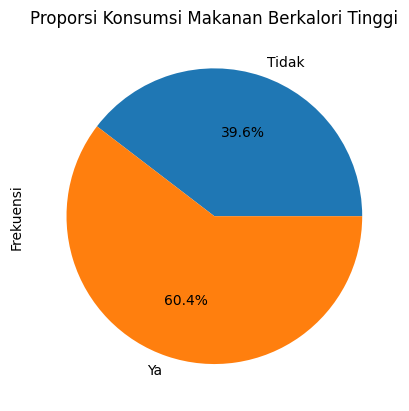

In [6]:
import matplotlib.pyplot as plt

frq_hfc.plot(kind='pie', y='Frekuensi', title="Proporsi Konsumsi Makanan Berkalori Tinggi", autopct='%1.1f%%', legend=False)
plt.show()

>Grafik Bar untuk High-calorie Food Consumption

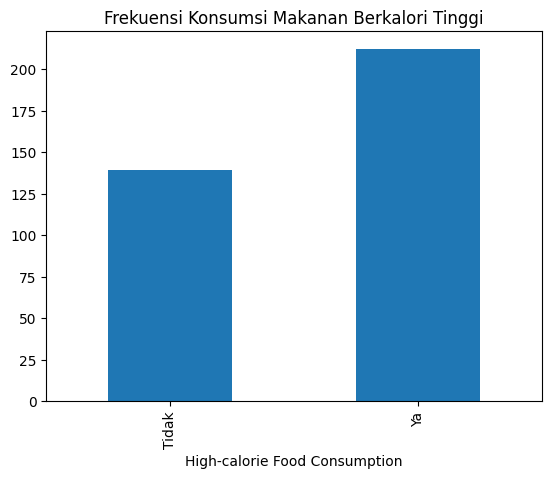

In [7]:
frq_hfc.plot(kind='bar', title="Frekuensi Konsumsi Makanan Berkalori Tinggi", legend=False)
plt.show()

>Grafik Bar untuk Usia

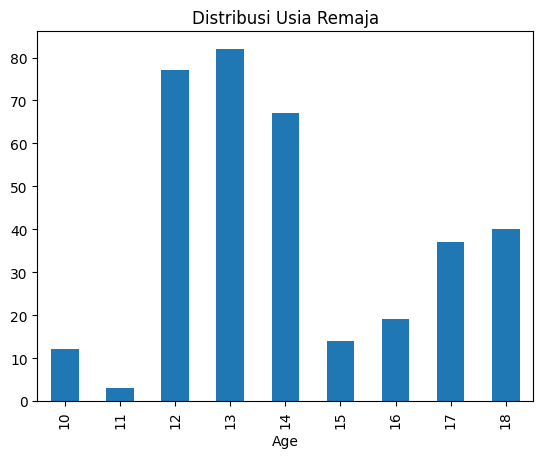

In [8]:
frq_usia.plot(kind='bar', title="Distribusi Usia Remaja", legend=False)
plt.show()

>Grafik Histogram untuk BMI (bins=15)

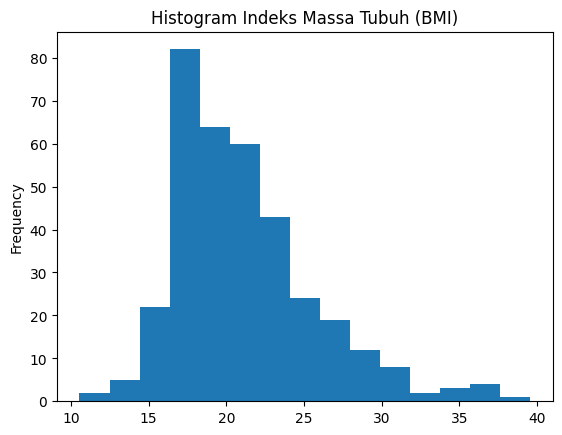

In [9]:
bmi.plot(kind='hist', bins=15, title="Histogram Indeks Massa Tubuh (BMI)")
plt.show()

>Grafik Histogram untuk Berat Badan (bins=15)

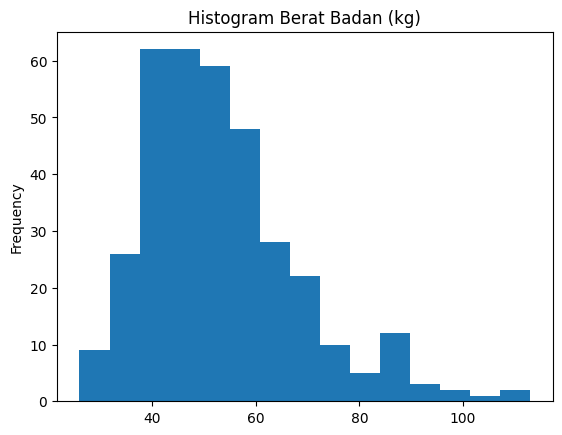

In [10]:
berat.plot(kind='hist', bins=15, title="Histogram Berat Badan (kg)")
plt.show()

>Grafik Boxplot Indeks Massa Tubuh

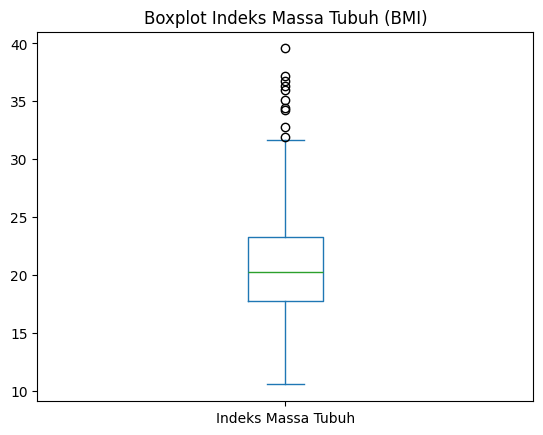

In [11]:
bmi.plot(kind='box', title="Boxplot Indeks Massa Tubuh (BMI)")
plt.show()

>Grafik Boxplot Berat Badan

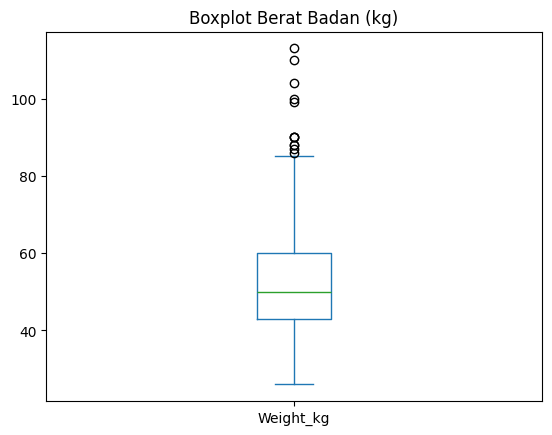

In [12]:
berat.plot(kind='box', title="Boxplot Berat Badan (kg)")
plt.show()

>Grafik Boxplot Usia Remaja

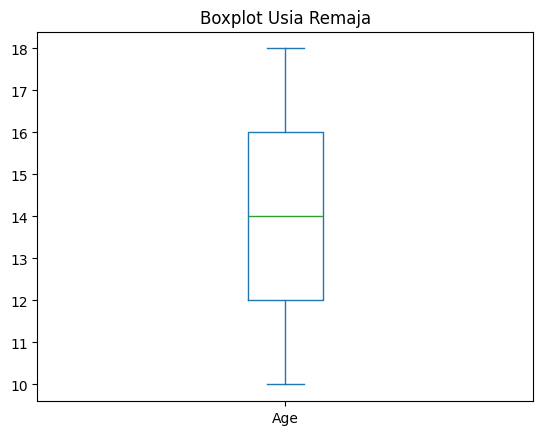

In [13]:
usia.plot(kind='box', title="Boxplot Usia Remaja")
plt.show()

###BAGIAN 4 - Statistika Deskriptif & Deteksi Outlier

In [18]:
# Statistika Deskriptif BMI
stats_bmi = bmi.describe()
stats_bmi['Standard Error'] = bmi.sem()
stats_bmi['Median'] = bmi.median()
stats_bmi['Mode'] = bmi.mode().iloc[0]
stats_bmi['variance'] = bmi.var()
stats_bmi['range'] = bmi.max() - bmi.min()
stats_bmi['skewness'] = bmi.skew()
stats_bmi['kurtosis'] = bmi.kurtosis()
iqr_bmi = stats_bmi['75%'] - stats_bmi['25%']
stats_bmi['IQR'] = iqr_bmi
stats_bmi['Batas Bawah'] = stats_bmi['25%'] - (1.5 * iqr_bmi)
stats_bmi['Batas Atas'] = stats_bmi['75%'] + (1.5 * iqr_bmi)
stats_bmi['SD/Mean (%)'] = (stats_bmi['std'] / stats_bmi['mean']) * 100
outlier_bmi = (bmi < stats_bmi['Batas Bawah']) | (bmi > stats_bmi['Batas Atas'])
stats_bmi['Jumlah Outlier'] = outlier_bmi.sum()

print("Statistika Deskriptif BMI:")
print(round(stats_bmi, 4))

# Statistika Deskriptif Berat Badan
stats_berat = berat.describe()
stats_berat['Standard Error'] = berat.sem()
stats_berat['Median'] = berat.median()
stats_berat['Mode'] = berat.mode().iloc[0]
stats_berat['variance'] = berat.var()
stats_berat['range'] = berat.max() - berat.min()
stats_berat['skewness'] = berat.skew()
stats_berat['kurtosis'] = berat.kurtosis()
iqr_berat = stats_berat['75%'] - stats_berat['25%']
stats_berat['IQR'] = iqr_berat
stats_berat['Batas Bawah'] = stats_berat['25%'] - (1.5 * iqr_berat)
stats_berat['Batas Atas'] = stats_berat['75%'] + (1.5 * iqr_berat)
stats_berat['SD/Mean (%)'] = (stats_berat['std'] / stats_berat['mean']) * 100
outlier_berat = (berat < stats_berat['Batas Bawah']) | (berat > stats_berat['Batas Atas'])
stats_berat['Jumlah Outlier'] = outlier_berat.sum()

print("\nStatistika Deskriptif Berat Badan:")
print(round(stats_berat, 4))

# Statistika Deskriptif Usia
stats_usia = usia.describe()
stats_usia['Standard Error'] = usia.sem()
stats_usia['Median'] = usia.median()
stats_usia['Mode'] = usia.mode().iloc[0]
stats_usia['variance'] = usia.var()
stats_usia['range'] = usia.max() - usia.min()
stats_usia['skewness'] = usia.skew()
stats_usia['kurtosis'] = usia.kurtosis()
iqr_usia = stats_usia['75%'] - stats_usia['25%']
stats_usia['IQR'] = iqr_usia
stats_usia['Batas Bawah'] = stats_usia['25%'] - (1.5 * iqr_usia)
stats_usia['Batas Atas'] = stats_usia['75%'] + (1.5 * iqr_usia)
stats_usia['SD/Mean (%)'] = (stats_usia['std'] / stats_usia['mean']) * 100
outlier_usia = (usia < stats_usia['Batas Bawah']) | (usia > stats_usia['Batas Atas'])
stats_usia['Jumlah Outlier'] = outlier_usia.sum()

print("\nStatistika Deskriptif Usia:")
print(round(stats_usia, 4))

# Groupby Deskriptif (Fokus pada BMI dan Berat berdasarkan Gender)
print("\nDeskriptif BMI berdasarkan Gender:")
print(round(data.groupby("Gender")["Indeks Massa Tubuh"].describe(), 4))

Statistika Deskriptif BMI:
count             351.0000
mean               21.0598
std                 4.6138
min                10.5500
25%                17.7350
50%                20.2400
75%                23.3150
max                39.5600
Standard Error      0.2463
Median             20.2400
Mode               16.6500
variance           21.2872
range              29.0100
skewness            1.0935
kurtosis            1.5752
IQR                 5.5800
Batas Bawah         9.3650
Batas Atas         31.6850
SD/Mean (%)        21.9081
Jumlah Outlier     10.0000
Name: Indeks Massa Tubuh, dtype: float64

Statistika Deskriptif Berat Badan:
count             351.0000
mean               53.1979
std                14.7095
min                26.0000
25%                43.0000
50%                50.0000
75%                60.0000
max               113.0000
Standard Error      0.7851
Median             50.0000
Mode               50.0000
variance          216.3689
range              87.0000
skewn

###BAGIAN 5 - Hubungan Usia dan BMI

Hipotesis Uji Hubungan (Korelasi):
H0: Tidak ada hubungan antara Usia dan BMI pada remaja.
H1: Terdapat hubungan antara Usia dan BMI pada remaja.

Hasil Uji Korelasi Pearson:
r = 0.2023 | p-value = 0.0001

Hasil Uji Korelasi Spearman:
rho = 0.2143 | p-value = 0.0001

Hasil Regresi Linear Sederhana (BMI = Intercept + Slope * Usia):
Slope = 0.4273
Intercept = 15.0409
R-squared = 0.0409
p-value = 0.0001


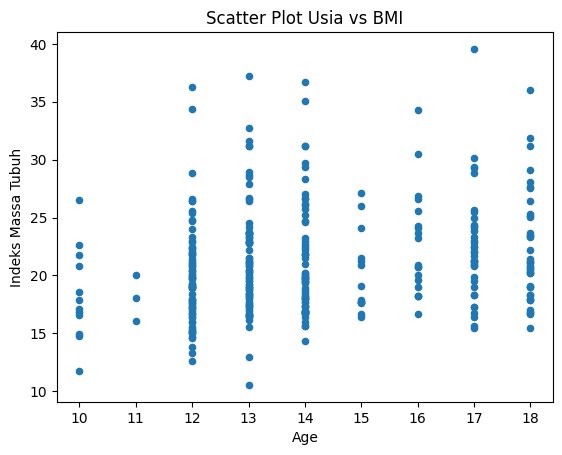

In [15]:
from scipy.stats import pearsonr, spearmanr, linregress

# Grafik Scatter Plot Usia vs BMI
data.plot(kind='scatter', x='Age', y='Indeks Massa Tubuh', title="Scatter Plot Usia vs BMI")

# Cetak Hipotesis
print("Hipotesis Uji Hubungan (Korelasi):")
print("H0: Tidak ada hubungan antara Usia dan BMI pada remaja.")
print("H1: Terdapat hubungan antara Usia dan BMI pada remaja.\n")

# Uji Pearson (Korelasi Linear / Parametrik)
r_pearson, p_pearson = pearsonr(data["Age"], data["Indeks Massa Tubuh"])
print("Hasil Uji Korelasi Pearson:")
print("r =", round(r_pearson, 4), "| p-value =", round(p_pearson, 4))

# Uji Spearman (Korelasi Peringkat / Non-Parametrik)
r_spearman, p_spearman = spearmanr(data["Age"], data["Indeks Massa Tubuh"])
print("\nHasil Uji Korelasi Spearman:")
print("rho =", round(r_spearman, 4), "| p-value =", round(p_spearman, 4))

# Regresi Linear Sederhana
slope, intercept, r_value, p_value, std_err = linregress(data["Age"], data["Indeks Massa Tubuh"])
print("\nHasil Regresi Linear Sederhana (BMI = Intercept + Slope * Usia):")
print("Slope =", round(slope, 4))
print("Intercept =", round(intercept, 4))
print("R-squared =", round(r_value**2, 4))
print("p-value =", round(p_value, 4))

###BAGIAN 6 - Uji Beda BMI Laki-laki vs Perempuan

Statistik BMI Kelompok Laki-laki:
Jumlah = 165 | Mean = 21.8615 | SD = 5.3563

Statistik BMI Kelompok Perempuan:
Jumlah = 186 | Mean = 20.3486 | SD = 3.7092

Hipotesis Uji Beda:
H0: Tidak terdapat perbedaan rata-rata BMI antara remaja laki-laki dan perempuan.
H1: Terdapat perbedaan rata-rata BMI antara remaja laki-laki dan perempuan.

Hasil Uji T-Test Independen (Welch's):
T-statistic = 3.0389 | p-value = 0.0026

Hasil Uji Mann-Whitney U:
U-statistic = 17624.0 | p-value = 0.0163


<Axes: title={'center': 'Indeks Massa Tubuh'}, xlabel='Gender'>

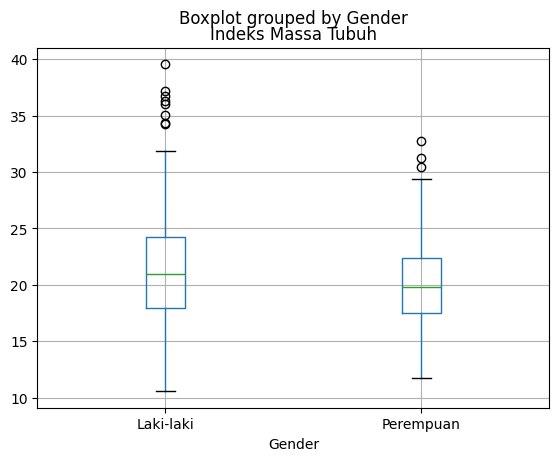

In [20]:
from scipy.stats import ttest_ind, mannwhitneyu

# Mendefinisikan Series BMI untuk Laki-laki dan Perempuan (Laki-laki menggunakan str.contains)
lk = data[data["Gender"].str.contains('Laki')]["Indeks Massa Tubuh"]
pr = data[data["Gender"] == 'Perempuan']["Indeks Massa Tubuh"]

# Statistik deskriptif dasar per kelompok
print("Statistik BMI Kelompok Laki-laki:")
print("Jumlah =", len(lk), "| Mean =", round(lk.mean(), 4), "| SD =", round(lk.std(), 4))
print("\nStatistik BMI Kelompok Perempuan:")
print("Jumlah =", len(pr), "| Mean =", round(pr.mean(), 4), "| SD =", round(pr.std(), 4))

# Cetak Hipotesis
print("\nHipotesis Uji Beda:")
print("H0: Tidak terdapat perbedaan rata-rata BMI antara remaja laki-laki dan perempuan.")
print("H1: Terdapat perbedaan rata-rata BMI antara remaja laki-laki dan perempuan.\n")

# Uji T Independen (Asumsi varians berbeda / Welch's t-test)
t_stat, p_ttest = ttest_ind(lk, pr, equal_var=False)
print("Hasil Uji T-Test Independen (Welch's):")
print("T-statistic =", round(t_stat, 4), "| p-value =", round(p_ttest, 4))

# Uji Mann-Whitney U (Non-Parametrik)
u_stat, p_mann = mannwhitneyu(lk, pr)
print("\nHasil Uji Mann-Whitney U:")
print("U-statistic =", round(u_stat, 4), "| p-value =", round(p_mann, 4))

# Visualisasi Boxplot BMI Laki-laki dan Perempuan
data.boxplot(column="Indeks Massa Tubuh", by="Gender")